# MS1 and MS2 tolerance identification through ReFRAME library dataset

In [1]:
import os
import json
import numpy as np
from benchmarking.optimization import (
    generate_ms_tolerance_data,
    generate_cosine_variance_outputs,
)
from benchmarking.plots import plot_varied_tolerance_metrics

# Dataset generation

## MS1 and MS2 cosine similarity tolerance datasets

In [2]:
base_dir_internal = "../data/groundtruth_dataset"
internal_datasets = ["MSV000098263"]  # For reframe drug library

In [3]:
input_feature_tables = []

for dataset in internal_datasets:
    input_dir = f"{base_dir_internal}/{dataset}/harmonized"
    if not os.path.exists(input_dir):
        print(f"Directory {input_dir} does not exist. Skipping dataset {dataset}.")
        continue

    for file in os.listdir(input_dir):
        input_feature_tables.append(f"{input_dir}/{file}")

In [4]:
output_feature_dirs = []

for file_path in input_feature_tables:
    output_feature_dirs.append(
        file_path.replace("harmonized", "annotated_cosine_varied")
    )
    os.makedirs(os.path.dirname(output_feature_dirs[-1]), exist_ok=True)

In [5]:
ms2_da_tolerances = np.concat(
    (
        np.array([0.00001, 0.0001, 0.0005]),
        np.arange(0.001, 0.01, 0.0005),
        np.array(
            [
                0.01,
                0.015,
            ]
        ),
        np.arange(0.02, 1, 0.01),
    )
)

ms1_ppm_tolerance = np.concatenate((np.arange(10, 20, 1), np.arange(20, 110, 10)))

### MS1 based tolerances

In [6]:
generate_ms_tolerance_data(
    input_feature_tables=input_feature_tables,
    output_feature_dirs=output_feature_dirs,
    ms_tolerances=ms1_ppm_tolerance,
    ms_tolerance_type="ms1",
)

Library loaded and processed.


Processing MS tolerances for MSV000098263_msdial_harmonized.parquet:   0%|          | 0/19 [00:00<?, ?it/s]/home/yojana.gadiya/benchmarking-untargeted-metabolomics-software/benchmarking/similarity/cosine_similarity.py:147: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  ai = A_list[i]
Processing MS tolerances for MSV000098263_msdial_harmonized.parquet: 100%|██████████| 19/19 [09:00<00:00, 28.45s/it]
Processing MS tolerances for MSV000098263_metaboscape_harmonized.parquet: 100%|██████████| 19/19 [09:41<00:00, 30.61s/it]
Processing MS tolerances for MSV000098263_mzmine_harmonized.parquet: 100%|██████████| 19/19 [10:45<00:00, 33.99s/it]


Processing completed. 0/57 outputs already existed and were skipped.


### MS2 based tolerances

In [7]:
generate_ms_tolerance_data(
    input_feature_tables=input_feature_tables,
    output_feature_dirs=output_feature_dirs,
    ms_tolerances=ms2_da_tolerances,
    ms_tolerance_type="ms2",
)

Library loaded and processed.


Processing MS tolerances for MSV000098263_msdial_harmonized.parquet: 100%|██████████| 121/121 [36:31<00:00, 18.11s/it]
Processing MS tolerances for MSV000098263_metaboscape_harmonized.parquet: 100%|██████████| 121/121 [11:44<00:00,  5.82s/it]
Processing MS tolerances for MSV000098263_mzmine_harmonized.parquet: 100%|██████████| 121/121 [19:39<00:00,  9.75s/it]

Processing completed. 0/363 outputs already existed and were skipped.


# Generate the tolerance metrics outputs

In [8]:
generate_cosine_variance_outputs(
    input_feature_tables=input_feature_tables,
    ms1_ppm_tolerance=ms1_ppm_tolerance,
    ms2_ppm_tolerances=ms2_da_tolerances,
    ground_truth_library_path="../data/library_spectra/reframe_spikein_lib.pq",
    varied_cosine_output_path="../data/groundtruth_dataset/MSV000098263/varied_cosine_output_tolerances.json",
)

Processing ms1 tolerances for MSV000098263_msdial_harmonized.parquet:  16%|█▌        | 3/19 [00:43<03:53, 14.61s/it]

Processing ms1 tolerances for MSV000098263_msdial_harmonized.parquet: 100%|██████████| 19/19 [04:47<00:00, 15.11s/it]
Processing ms2 tolerances for MSV000098263_msdial_harmonized.parquet: 100%|██████████| 121/121 [31:16<00:00, 15.51s/it]
Processing ms1 tolerances for MSV000098263_metaboscape_harmonized.parquet: 100%|██████████| 19/19 [02:28<00:00,  7.82s/it]
Processing ms2 tolerances for MSV000098263_metaboscape_harmonized.parquet: 100%|██████████| 121/121 [15:23<00:00,  7.63s/it]
Processing ms1 tolerances for MSV000098263_mzmine_harmonized.parquet: 100%|██████████| 19/19 [03:28<00:00, 10.96s/it]
Processing ms2 tolerances for MSV000098263_mzmine_harmonized.parquet: 100%|██████████| 121/121 [20:02<00:00,  9.94s/it]


In [9]:
# Load the generated varied cosine output for further analysis
varied_cosine_output = json.load(
    open(
        "../data/groundtruth_dataset/MSV000098263/varied_cosine_output_tolerances.json",
        "r",
    )
)
len(varied_cosine_output)

3

# MS1 tolerance against F1 score

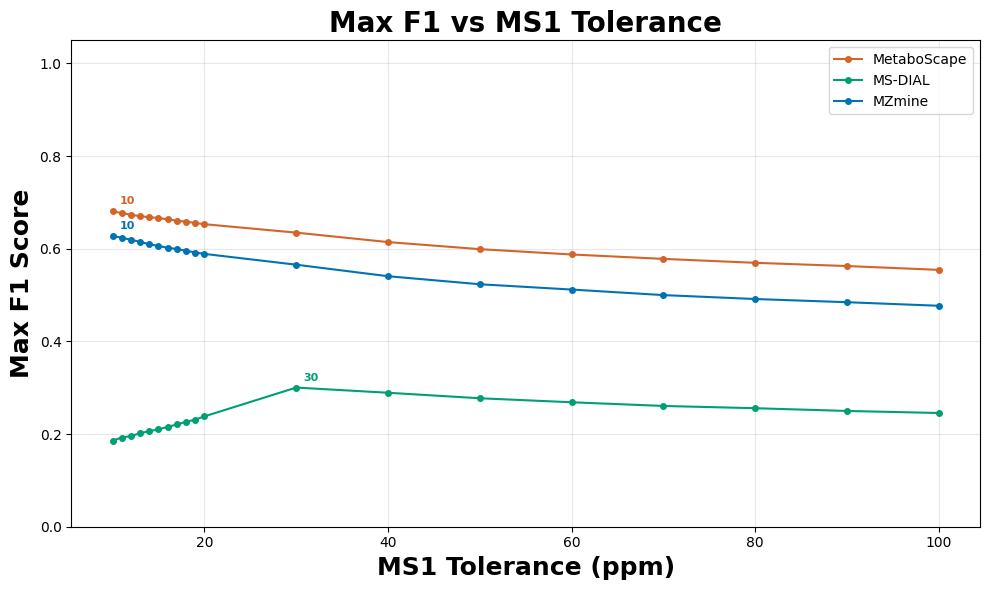

In [10]:
plot_varied_tolerance_metrics(
    varied_cosine_output,
    ms_tol_type="ms1",
    metric="max_f1",
    title="Max F1 vs MS1 Tolerance",
    display_argmax=True,
    xaxis_label="MS1 Tolerance (ppm)",
    yaxis_label="Max F1 Score",
    save_path="../figures/supplementary_figure_1.png",
    figsize=(10, 6),
)

# MS2 tolerance against F1 score

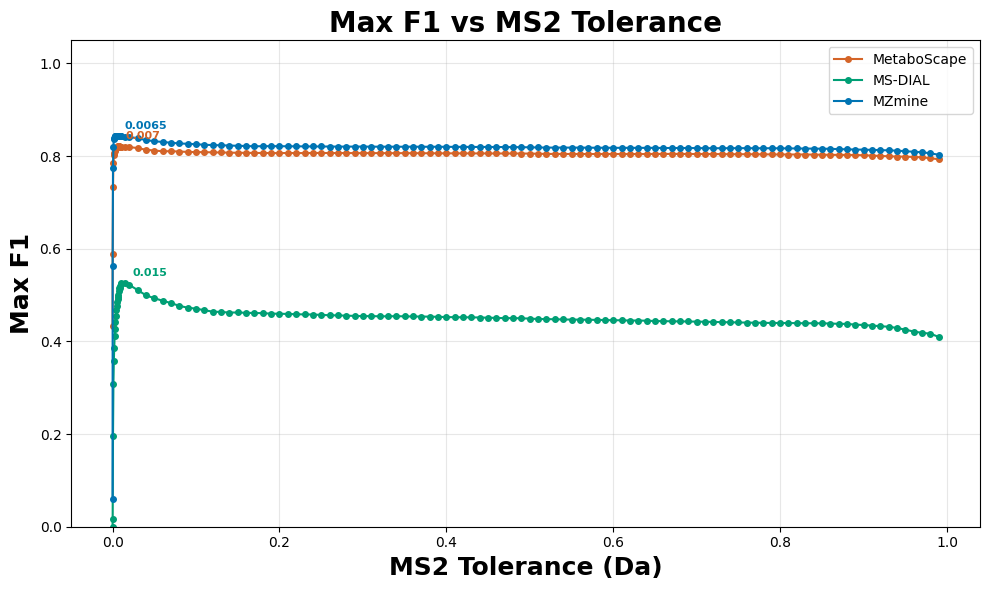

In [11]:
plot_varied_tolerance_metrics(
    varied_cosine_output,
    ms_tol_type="ms2",
    metric="max_f1",
    title="Max F1 vs MS2 Tolerance",
    display_argmax=True,
    xaxis_label="MS2 Tolerance (Da)",
    save_path="../figures/supplementary_figure_2.png",
    figsize=(10, 6),
)